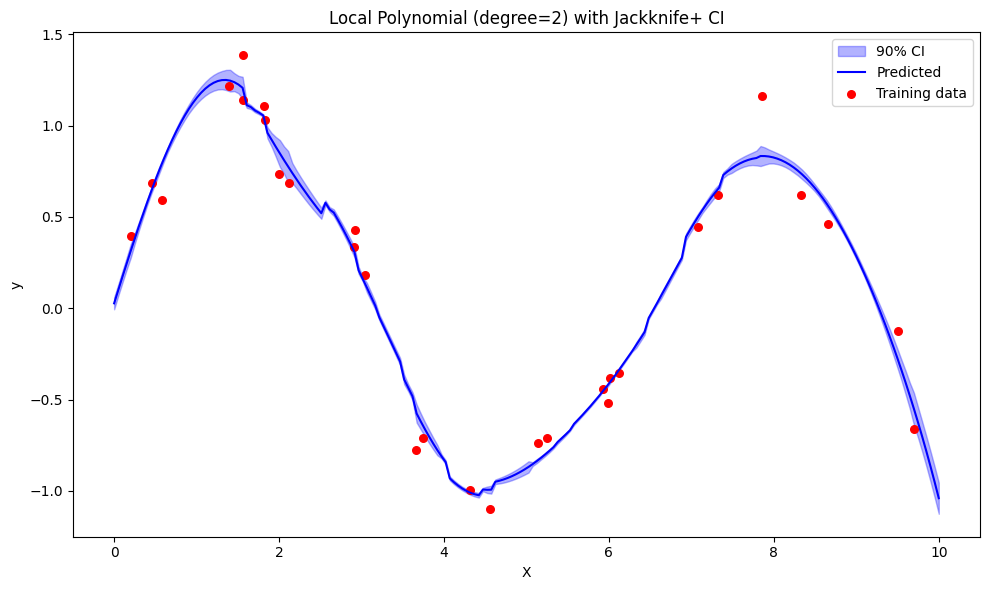

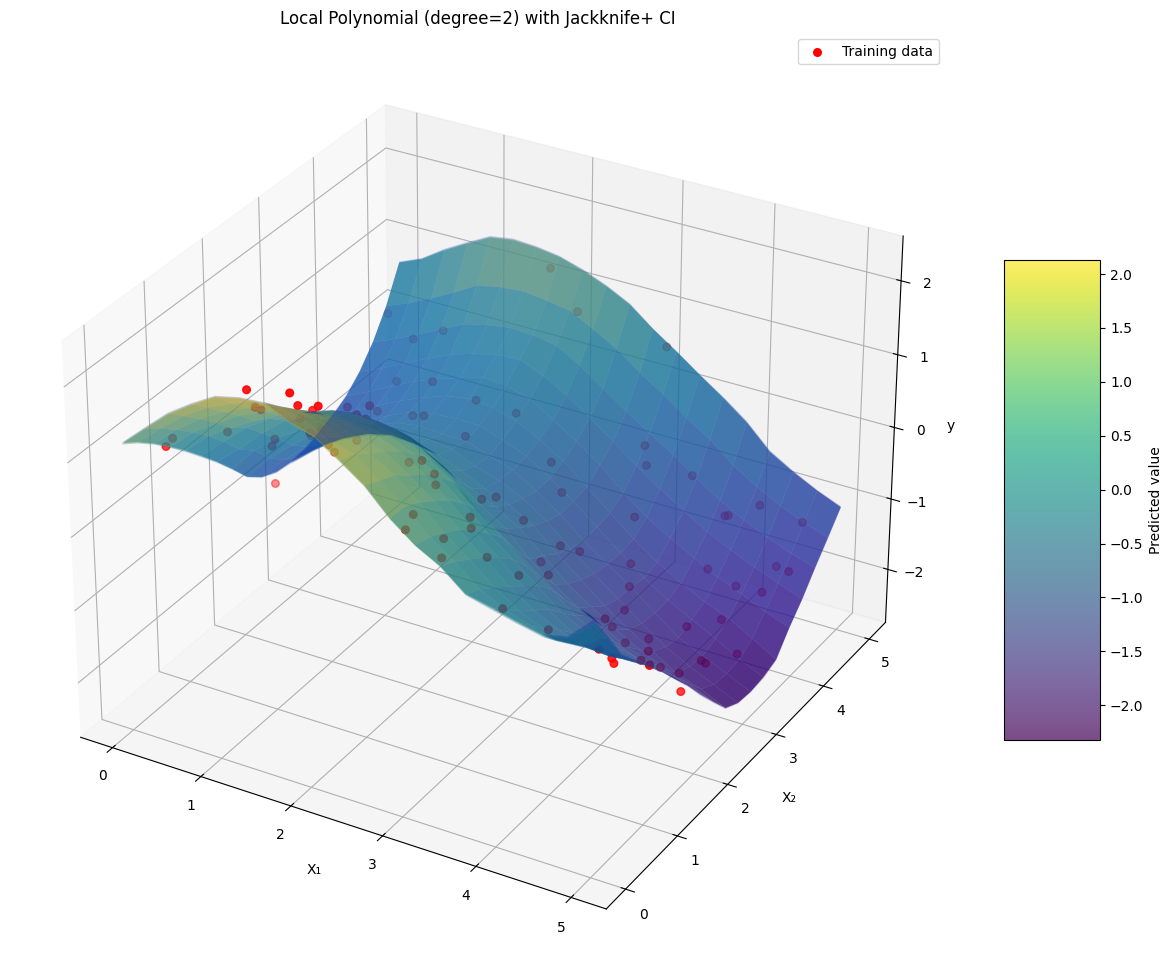

In [9]:
import numpy as np
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

class LocalPolynomialInterpolation:
    """
    Implements local polynomial interpolation with jackknife+ confidence intervals.
    
    The class uses a weighted local polynomial regression approach where only
    the K nearest points to the target point are used for fitting. The jackknife+
    method is used to compute confidence intervals with non-conformity scores
    based on neighborhood structure.
    """
    
    def __init__(self, degree=2, kernel='gaussian', n_neighbors=None, bandwidth=1.0):
        """
        Initialize the local polynomial interpolation.
        
        Parameters:
        -----------
        degree : int
            Degree of the polynomial features.
        kernel : str
            Kernel function to use for weighting ('gaussian', 'epanechnikov', or 'uniform').
        n_neighbors : int or None
            Number of nearest neighbors to use for local fitting.
            If None, all points are used with distance-based weighting.
        bandwidth : float
            Bandwidth parameter controlling the locality of the regression.
        """
        self.degree = degree
        self.kernel = kernel
        self.n_neighbors = n_neighbors
        self.bandwidth = bandwidth
        self.poly = PolynomialFeatures(degree=degree, include_bias=True)
        
    def _kernel_function(self, distances):
        """
        Compute kernel weights based on distances.
        
        Parameters:
        -----------
        distances : array-like
            Distances from the target point to training points.
            
        Returns:
        --------
        weights : array-like
            Kernel weights for each point.
        """
        scaled_dist = distances / self.bandwidth
        
        if self.kernel == 'gaussian':
            weights = np.exp(-0.5 * (scaled_dist ** 2))
        elif self.kernel == 'epanechnikov':
            weights = np.maximum(0, 1 - scaled_dist ** 2) * 0.75
        elif self.kernel == 'uniform':
            weights = (scaled_dist <= 1.0).astype(float)
        else:
            raise ValueError(f"Unknown kernel: {self.kernel}")
            
        return weights
    
    def _local_fit(self, X_train, y_train, x_target, indices=None, sample_weight=None):
        """
        Perform a local polynomial fit at a target point.
        
        Parameters:
        -----------
        X_train : array-like of shape (n_samples, n_features)
            Training input data.
        y_train : array-like of shape (n_samples,)
            Target values.
        x_target : array-like of shape (n_features,)
            Point at which to make the prediction.
        indices : array-like of shape (K,) or None
            Indices of neighbors to use for local fitting.
            If None, all points are used.
        sample_weight : array-like of shape (K,) or None
            Sample weights for the fit.
            
        Returns:
        --------
        prediction : float
            Predicted value at the target point.
        """
        # Use all data points if indices is None
        if indices is None:
            X_subset = X_train
            y_subset = y_train
            distances = np.sqrt(np.sum((X_train - x_target) ** 2, axis=1))
            local_weights = self._kernel_function(distances)
        else:
            X_subset = X_train[indices]
            y_subset = y_train[indices]
            distances = np.sqrt(np.sum((X_subset - x_target) ** 2, axis=1))
            local_weights = self._kernel_function(distances)
            
        # Use provided sample weights if any
        if sample_weight is not None:
            local_weights = sample_weight
        
        # Skip the fit if all weights are zero
        if np.sum(local_weights) <= 1e-10:
            return np.nan
        
        # Create polynomial features
        X_poly = self.poly.fit_transform(X_subset)
        
        # Fit weighted linear regression
        model = LinearRegression()
        model.fit(X_poly, y_subset, sample_weight=local_weights)
        
        # Transform the target point and predict
        x_target_poly = self.poly.transform(x_target.reshape(1, -1))
        prediction = model.predict(x_target_poly)[0]
        
        return prediction
    
    def _get_nearest_neighbors(self, X_train, x_target):
        """
        Find the K nearest neighbors of a target point.
        
        Parameters:
        -----------
        X_train : array-like of shape (n_samples, n_features)
            Training input data.
        x_target : array-like of shape (n_features,)
            Target point.
            
        Returns:
        --------
        indices : array-like of shape (K,)
            Indices of the K nearest neighbors.
        distances : array-like of shape (K,)
            Distances to the K nearest neighbors.
        """
        if self.n_neighbors is None:
            # If n_neighbors is None, return all indices
            distances = np.sqrt(np.sum((X_train - x_target) ** 2, axis=1))
            indices = np.arange(len(X_train))
        else:
            # Otherwise, return only the K nearest neighbors
            nbrs = NearestNeighbors(n_neighbors=min(self.n_neighbors, len(X_train)))
            nbrs.fit(X_train)
            distances, indices = nbrs.kneighbors(x_target.reshape(1, -1))
            distances = distances.ravel()
            indices = indices.ravel()
            
        return indices, distances
    
    def predict(self, X_train, y_train, X_target):
        """
        Make predictions at target points using local polynomial regression.
        
        Parameters:
        -----------
        X_train : array-like of shape (n_samples, n_features)
            Training input data.
        y_train : array-like of shape (n_samples,)
            Target values.
        X_target : array-like of shape (n_targets, n_features)
            Points at which to make predictions.
            
        Returns:
        --------
        predictions : array-like of shape (n_targets,)
            Predicted values at the target points.
        """
        X_train = np.asarray(X_train)
        y_train = np.asarray(y_train)
        X_target = np.asarray(X_target)
        
        predictions = np.zeros(X_target.shape[0])
        
        for i, x_target in enumerate(X_target):
            # Get nearest neighbors
            indices, _ = self._get_nearest_neighbors(X_train, x_target)
            
            # Local fit using only the nearest neighbors
            predictions[i] = self._local_fit(X_train, y_train, x_target, indices)
            
        return predictions
    
    def jackknife_plus(self, X_train, y_train, X_target, alpha=0.1):
        """
        Compute jackknife+ confidence intervals using neighborhood structure.
        
        Parameters:
        -----------
        X_train : array-like of shape (n_samples, n_features)
            Training input data.
        y_train : array-like of shape (n_samples,)
            Target values.
        X_target : array-like of shape (n_targets, n_features)
            Points at which to make predictions.
        alpha : float
            Desired miscoverage level (e.g., 0.1 for 90% confidence intervals).
            
        Returns:
        --------
        predictions : array-like of shape (n_targets,)
            Predicted values at the target points.
        lower_bounds : array-like of shape (n_targets,)
            Lower bounds of the confidence intervals.
        upper_bounds : array-like of shape (n_targets,)
            Upper bounds of the confidence intervals.
        """
        X_train = np.asarray(X_train)
        y_train = np.asarray(y_train)
        X_target = np.asarray(X_target)
        
        n_train = X_train.shape[0]
        n_target = X_target.shape[0]
        
        # Storage for results
        full_predictions = np.zeros(n_target)
        loo_predictions = np.zeros((n_train, n_target))
        
        # Array to store neighbor info for each target point
        neighbor_info = []
        
        # For each target point, compute the full prediction
        # and store neighbor information
        for j, x_target in enumerate(X_target):
            # Get nearest neighbors for this target point
            indices, distances = self._get_nearest_neighbors(X_train, x_target)
            
            # Store neighbor indices and distances for this target point
            neighbor_info.append({
                'indices': indices,
                'distances': distances,
                'neighborhood_size': len(indices)
            })
            
            # Full model prediction using all neighbors
            full_predictions[j] = self._local_fit(X_train, y_train, x_target, indices)
        
        # For each leave-one-out sample
        for i in range(n_train):
            # Create leave-one-out dataset
            X_loo = np.delete(X_train, i, axis=0)
            y_loo = np.delete(y_train, i, axis=0)
            
            # For each target point
            for j, x_target in enumerate(X_target):
                # Get neighbor info for this target point
                neighbors = neighbor_info[j]
                
                # Check if the left-out point was in the neighborhood
                was_in_neighborhood = i in neighbors['indices']
                
                # If using KNN method, we need to recompute neighbors when leaving one out
                if was_in_neighborhood:
                    # Get new nearest neighbors (excluding the left-out point)
                    if self.n_neighbors is not None:
                        # If we're using a fixed number of neighbors, we need one more
                        # since we're removing one
                        nbrs = NearestNeighbors(
                            n_neighbors=min(self.n_neighbors + 1, n_train))
                        nbrs.fit(X_train)
                        nn_distances, nn_indices = nbrs.kneighbors(
                            x_target.reshape(1, -1))
                        
                        # Find and remove the left-out point from the neighbors
                        idx_to_remove = np.where(nn_indices[0] == i)[0]
                        if len(idx_to_remove) > 0:
                            nn_indices = np.delete(nn_indices[0], idx_to_remove)
                            nn_distances = np.delete(nn_distances[0], idx_to_remove)
                            
                            # Keep only up to n_neighbors
                            nn_indices = nn_indices[:self.n_neighbors]
                            nn_distances = nn_distances[:self.n_neighbors]
                        else:
                            # If left-out point wasn't in extended neighborhood
                            nn_indices = nn_indices[0, :self.n_neighbors]
                            nn_distances = nn_distances[0, :self.n_neighbors]
                        
                        # Make leave-one-out prediction with the new neighbors
                        loo_predictions[i, j] = self._local_fit(
                            X_train, y_train, x_target, nn_indices)
                    else:
                        # If using all points with weighting, just exclude the left-out point
                        indices = np.setdiff1d(np.arange(n_train), [i])
                        loo_predictions[i, j] = self._local_fit(
                            X_train, y_train, x_target, indices)
                else:
                    # If left-out point wasn't in the neighborhood, prediction is unchanged
                    loo_predictions[i, j] = full_predictions[j]
        
        # Compute non-conformity scores based on prediction differences
        non_conformity_scores = np.abs(loo_predictions - np.tile(full_predictions, (n_train, 1)))
        
        # Now, weight the non-conformity scores based on neighborhood membership
        weighted_scores = np.zeros_like(non_conformity_scores)
        
        for j in range(n_target):
            neighbors = neighbor_info[j]
            
            # Create a mask for points in the neighborhood
            in_neighborhood = np.isin(np.arange(n_train), neighbors['indices'])
            
            # Weight the scores - points in the neighborhood get higher weight
            # Points not in the neighborhood get a small weight (not zero to avoid discontinuities)
            weights = np.ones(n_train) * 0.1  # Base weight for non-neighbors
            
            # For points in the neighborhood, weight by inverse distance
            if np.any(in_neighborhood):
                # Get indices of points in the neighborhood
                idx = np.where(in_neighborhood)[0]
                
                # Get distances for these points
                dist = np.zeros(len(idx))
                for k, train_idx in enumerate(idx):
                    # Find position of train_idx in the neighbors['indices'] array
                    pos = np.where(neighbors['indices'] == train_idx)[0]
                    if len(pos) > 0:
                        dist[k] = neighbors['distances'][pos[0]]
                    else:
                        dist[k] = np.inf
                
                # Compute inverse distance weights (add small constant to avoid division by zero)
                inv_dist = 1.0 / (dist + 1e-10)
                
                # Normalize weights to sum to 1
                inv_dist = inv_dist / np.sum(inv_dist)
                
                # Assign weights - higher weight for closer points
                weights[idx] = inv_dist * 0.9 + 0.1  # Add base weight
            
            # Apply weights to non-conformity scores
            weighted_scores[:, j] = non_conformity_scores[:, j] * weights
        
        # Compute jackknife+ confidence intervals
        q_level = np.ceil((n_train + 1) * (1 - alpha)) / n_train
        quantiles = np.zeros(n_target)
        
        for j in range(n_target):
            # Use the non-conformity scores for points that were in the neighborhood
            # of this target point (they have more influence on the prediction)
            neighbors = neighbor_info[j]
            in_neighborhood = np.isin(np.arange(n_train), neighbors['indices'])
            
            if np.any(in_neighborhood):
                # Get the quantile from the weighted scores
                quantiles[j] = np.quantile(weighted_scores[in_neighborhood, j], q_level)
            else:
                # If no points in neighborhood (shouldn't happen), use all scores
                quantiles[j] = np.quantile(weighted_scores[:, j], q_level)
        
        lower_bounds = full_predictions - quantiles
        upper_bounds = full_predictions + quantiles
        
        return full_predictions, lower_bounds, upper_bounds
    
    def plot_interpolation_with_ci(self, X_train, y_train, X_target, alpha=0.1, 
                                  show_training_data=True, fig=None, ax=None):
        """
        Plot the interpolation and confidence intervals for 1D or 2D data.
        
        Parameters:
        -----------
        X_train : array-like of shape (n_samples, n_features)
            Training input data.
        y_train : array-like of shape (n_samples,)
            Target values.
        X_target : array-like of shape (n_targets, n_features)
            Points at which to make predictions.
        alpha : float
            Desired miscoverage level (e.g., 0.1 for 90% confidence intervals).
        show_training_data : bool
            Whether to show the training data points.
        fig, ax : matplotlib Figure and Axes, optional
            Figure and axes to use for plotting. If None, new ones are created.
            
        Returns:
        --------
        fig, ax : matplotlib Figure and Axes
            Figure and axes used for plotting.
        """
        X_train = np.asarray(X_train)
        y_train = np.asarray(y_train)
        X_target = np.asarray(X_target)
        
        # Compute predictions and confidence intervals
        predictions, lower_bounds, upper_bounds = self.jackknife_plus(
            X_train, y_train, X_target, alpha)
        
        # Create figure and axes if not provided
        if fig is None or ax is None:
            fig, ax = plt.subplots(figsize=(10, 6))
        
        # 1D case
        if X_train.shape[1] == 1:
            # Sort target points for smooth curve
            idx = np.argsort(X_target.ravel())
            x_sorted = X_target.ravel()[idx]
            y_pred_sorted = predictions[idx]
            lower_sorted = lower_bounds[idx]
            upper_sorted = upper_bounds[idx]
            
            # Plot confidence intervals
            ax.fill_between(x_sorted, lower_sorted, upper_sorted, 
                           alpha=0.3, color='blue', label=f'{(1-alpha)*100:.0f}% CI')
            
            # Plot predictions
            ax.plot(x_sorted, y_pred_sorted, 'b-', label='Predicted')
            
            # Plot training data
            if show_training_data:
                ax.scatter(X_train.ravel(), y_train, c='red', s=30, label='Training data')
            
            ax.set_xlabel('X')
            ax.set_ylabel('y')
            
        # 2D case (surface plot for X₁, X₂ vs y)
        elif X_train.shape[1] == 2:
            from mpl_toolkits.mplot3d import Axes3D
            
            # Convert to 3D axes if not already
            if not isinstance(ax, Axes3D):
                ax.remove()
                ax = fig.add_subplot(111, projection='3d')
            
            # Create a meshgrid for surface plot
            x_unique = np.unique(X_target[:, 0])
            y_unique = np.unique(X_target[:, 1])
            
            # Reshape predictions for surface plot
            X1, X2 = np.meshgrid(x_unique, y_unique)
            Z_pred = np.zeros_like(X1)
            Z_lower = np.zeros_like(X1)
            Z_upper = np.zeros_like(X1)
            
            for i, x1 in enumerate(x_unique):
                for j, x2 in enumerate(y_unique):
                    idx = np.where((X_target[:, 0] == x1) & (X_target[:, 1] == x2))[0]
                    if len(idx) > 0:
                        Z_pred[j, i] = predictions[idx[0]]
                        Z_lower[j, i] = lower_bounds[idx[0]]
                        Z_upper[j, i] = upper_bounds[idx[0]]
            
            # Plot predictions surface
            surf = ax.plot_surface(X1, X2, Z_pred, cmap='viridis', alpha=0.7,
                                  linewidth=0, antialiased=True)
            fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Predicted value')
            
            # Plot confidence interval surfaces (semi-transparent)
            ax.plot_surface(X1, X2, Z_lower, color='blue', alpha=0.2)
            ax.plot_surface(X1, X2, Z_upper, color='blue', alpha=0.2)
            
            # Plot training data
            if show_training_data:
                ax.scatter(X_train[:, 0], X_train[:, 1], y_train, c='red', s=30, label='Training data')
            
            ax.set_xlabel('X₁')
            ax.set_ylabel('X₂')
            ax.set_zlabel('y')
            
        else:
            raise ValueError("Plotting only supports 1D or 2D features")
        
        ax.set_title(f'Local Polynomial (degree={self.degree}) with Jackknife+ CI')
        ax.legend()
        
        return fig, ax


# Example usage
if __name__ == "__main__":
    # Generate synthetic data
    np.random.seed(42)
    
    # 1D example
    def f1d(x):
        return np.sin(x) + 0.2 * np.sin(5*x)
    
    X_train_1d = np.random.uniform(0, 10, size=(30, 1))
    y_train_1d = f1d(X_train_1d.ravel()) + 0.1 * np.random.randn(30)
    
    X_target_1d = np.linspace(0, 10, 200).reshape(-1, 1)
    
    # Create and fit model
    lpi_1d = LocalPolynomialInterpolation(degree=2, kernel='gaussian', n_neighbors=10)
    
    # Plot results
    fig1, ax1 = plt.subplots(figsize=(10, 6))
    fig1, ax1 = lpi_1d.plot_interpolation_with_ci(
        X_train_1d, y_train_1d, X_target_1d, alpha=0.1, fig=fig1, ax=ax1)
    plt.tight_layout()
    
    # 2D example
    def f2d(x1, x2):
        return np.sin(x1) + np.cos(x2) + 0.2 * np.sin(3*x1*x2)
    
    X_train_2d = np.random.uniform(0, 5, size=(100, 2))
    y_train_2d = f2d(X_train_2d[:, 0], X_train_2d[:, 1]) + 0.1 * np.random.randn(100)
    
    # Create grid for visualization
    x1_grid = np.linspace(0, 5, 20)
    x2_grid = np.linspace(0, 5, 20)
    X1, X2 = np.meshgrid(x1_grid, x2_grid)
    X_target_2d = np.column_stack((X1.ravel(), X2.ravel()))
    
    # Create and fit model
    lpi_2d = LocalPolynomialInterpolation(degree=2, kernel='gaussian', n_neighbors=20)
    
    # Plot results
    fig2 = plt.figure(figsize=(12, 10))
    ax2 = fig2.add_subplot(111, projection='3d')
    fig2, ax2 = lpi_2d.plot_interpolation_with_ci(
        X_train_2d, y_train_2d, X_target_2d, alpha=0.1, fig=fig2, ax=ax2)
    plt.tight_layout()
    
    plt.show()